In [1]:
import os
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset
from torchvision import transforms, models
from PIL import Image
import pandas as pd
import matplotlib.pyplot as plt
from tqdm import tqdm

# ==========================================
# 1. CONFIGURATION ET DETECTION DU DOSSIER
# ==========================================
import os
import torch

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"🖥️ Utilisation de : {device}")

chemin_dossier = None

# On parcourt récursivement /kaggle/input pour trouver le fichier automatiquement
for root, dirs, files in os.walk('/kaggle/input'):
    if "train.csv" in files:
        chemin_dossier = root
        break

if chemin_dossier is None:
    # Si la recherche automatique échoue, on vérifie manuellement le répertoire courant
    if os.path.exists("train.csv"):
        chemin_dossier = "."
    else:
        raise FileNotFoundError("❌ Impossible de trouver train.csv. Vérifiez que le dataset est ajouté dans le panneau 'Data' à droite.")

print(f"✅ Dossier trouvé : {chemin_dossier}")


# ==========================================
# 2. DATASET ET TRANSFORMATIONS
# ==========================================
class SeaShipDataset(Dataset):
    def __init__(self, csv_file, img_dir, transform=None):
        self.df = pd.read_csv(csv_file)
        self.img_dir = img_dir
        self.transform = transform
        self.classes = sorted(self.df.iloc[:, 1].unique().astype(str).tolist())
        self.class_to_idx = {cls: i for i, cls in enumerate(self.classes)}
        
    def __len__(self):
        return len(self.df)
        
    def __getitem__(self, idx):
        nom_img = str(self.df.iloc[idx, 0])
        if not nom_img.lower().endswith(('.jpg', '.png', '.jpeg')): nom_img += '.jpg'
        image = Image.open(os.path.join(self.img_dir, nom_img)).convert('RGB')
        label = self.class_to_idx[str(self.df.iloc[idx, 1])]
        if self.transform: image = self.transform(image)
        return image, label

transformations = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

train_ds = SeaShipDataset(os.path.join(chemin_dossier, "train.csv"), os.path.join(chemin_dossier, "train_images"), transformations)
test_ds = SeaShipDataset(os.path.join(chemin_dossier, "test.csv"), os.path.join(chemin_dossier, "test_images"), transformations)

train_loader = DataLoader(train_ds, batch_size=32, shuffle=True)
test_loader = DataLoader(test_ds, batch_size=32, shuffle=False)

# ==========================================
# 3. LES DEUX ARCHITECTURES
# ==========================================

# Architecture 1 : CNN Maison
class CNN_Maison(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(32, 64, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(64, 128, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(128, 256, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(256 * 14 * 14, 512), nn.ReLU(), nn.Dropout(0.5),
            nn.Linear(512, num_classes)
        )
    def forward(self, x): return self.classifier(self.features(x))

# Architecture 2 : ResNet18 (Transfer Learning)
def creer_resnet18(num_classes):
    # On utilise des poids pré-entraînés pour gagner en efficacité
    modele = models.resnet18(weights='DEFAULT')
    num_ftrs = modele.fc.in_features
    modele.fc = nn.Linear(num_ftrs, num_classes) # On adapte la sortie
    return modele.to(device)

# ==========================================
# 4. FONCTION D'ENTRAÎNEMENT GÉNÉRIQUE
# ==========================================
def entrainer_modele(model, name, epochs=10):
    print(f"\n Entraînement de : {name}")
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=0.001)
    history = {'train_acc': [], 'test_acc': []}

    for epoch in range(epochs):
        model.train()
        correct, total = 0, 0
        for imgs, labels in tqdm(train_loader, desc=f"Ep {epoch+1}"):
            imgs, labels = imgs.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(imgs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            _, pred = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (pred == labels).sum().item()
        
        train_acc = 100 * correct / total
        
        # Test
        model.eval()
        correct, total = 0, 0
        with torch.no_grad():
            for imgs, labels in test_loader:
                imgs, labels = imgs.to(device), labels.to(device)
                outputs = model(imgs)
                _, pred = torch.max(outputs, 1)
                total += labels.size(0)
                correct += (pred == labels).sum().item()
        test_acc = 100 * correct / total
        
        history['train_acc'].append(train_acc)
        history['test_acc'].append(test_acc)
        print(f"✅ {name} - Epoch {epoch+1}: Train {train_acc:.1f}% | Test {test_acc:.1f}%")
        
    return history

# ==========================================
# 5. LANCEMENT DE LA COMPARAISON
# ==========================================
nb_classes = len(train_ds.classes)
nb_epoques = 10

# Entraîner le CNN Maison
history_maison = entrainer_modele(CNN_Maison(nb_classes).to(device), "CNN Maison", epochs=nb_epoques)



🖥️ Utilisation de : cuda
✅ Dossier trouvé : /kaggle/input/datasets/tangwenyang/seaship/SeaShip

 Entraînement de : CNN Maison


Ep 1: 100%|██████████| 175/175 [03:19<00:00,  1.14s/it]


✅ CNN Maison - Epoch 1: Train 41.5% | Test 51.2%


Ep 2: 100%|██████████| 175/175 [02:24<00:00,  1.21it/s]


✅ CNN Maison - Epoch 2: Train 57.6% | Test 66.2%


...

✅ CNN Maison - Epoch 8: Train 92.5% | Test 89.6%


Ep 9: 100%|██████████| 175/175 [02:15<00:00,  1.29it/s]


✅ CNN Maison - Epoch 9: Train 94.4% | Test 91.1%


Ep 10: 100%|██████████| 175/175 [02:16<00:00,  1.28it/s]


✅ CNN Maison - Epoch 10: Train 94.8% | Test 92.2%


In [2]:
# Entraîner ResNet18
history_resnet = entrainer_modele(creer_resnet18(nb_classes), "ResNet18", epochs=nb_epoques)

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 174MB/s] 



 Entraînement de : ResNet18


Ep 1: 100%|██████████| 175/175 [02:19<00:00,  1.25it/s]


✅ ResNet18 - Epoch 1: Train 71.7% | Test 79.1%


...

✅ ResNet18 - Epoch 8: Train 95.6% | Test 91.3%


Ep 9: 100%|██████████| 175/175 [02:14<00:00,  1.30it/s]


✅ ResNet18 - Epoch 9: Train 96.6% | Test 93.4%


Ep 10: 100%|██████████| 175/175 [02:15<00:00,  1.29it/s]


✅ ResNet18 - Epoch 10: Train 97.7% | Test 93.6%


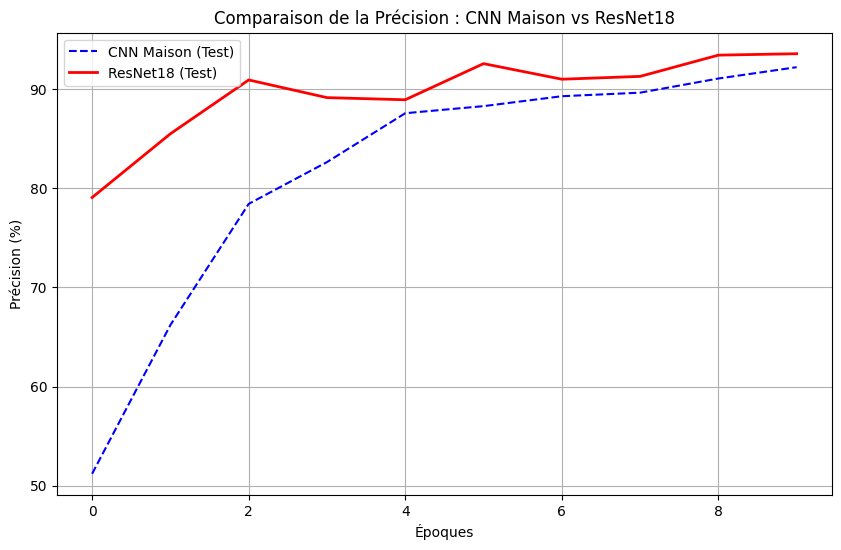


 Analyse terminée. ResNet18 devrait normalement être plus stable et précis.


In [3]:
# ==========================================
# 6. GRAPHIQUE COMPARATIF FINAL
# ==========================================
plt.figure(figsize=(10, 6))
plt.plot(history_maison['test_acc'], label='CNN Maison (Test)', color='blue', linestyle='--')
plt.plot(history_resnet['test_acc'], label='ResNet18 (Test)', color='red', linewidth=2)

plt.title('Comparaison de la Précision : CNN Maison vs ResNet18')
plt.xlabel('Époques')
plt.ylabel('Précision (%)')
plt.legend()
plt.grid(True)
plt.show()

print("\n Analyse terminée. ResNet18 devrait normalement être plus stable et précis.")

In [6]:
# ==========================================
# 7. CALCUL DES MÉTRIQUES AVANCÉES
# ==========================================
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

def evaluer_modele(model, loader, nom):
    model.eval()
    y_true = []
    y_pred = []

    with torch.no_grad():
        for imgs, labels in loader:
            imgs = imgs.to(device)
            outputs = model(imgs)
            _, preds = torch.max(outputs, 1)

            y_true.extend(labels.cpu().numpy())
            y_pred.extend(preds.cpu().numpy())

    # Accuracy
    acc = accuracy_score(y_true, y_pred)

    # Rapport complet
    report = classification_report(y_true, y_pred, output_dict=True)

    # Moyennes globales
    precision = report['weighted avg']['precision']
    recall = report['weighted avg']['recall']
    f1 = report['weighted avg']['f1-score']

    # Matrice de confusion
    cm = confusion_matrix(y_true, y_pred)

    print(f"\n Résultats pour {nom} :")
    print(f"Accuracy  : {acc*100:.2f}%")
    print(f"Precision : {precision*100:.2f}%")
    print(f"Recall    : {recall*100:.2f}%")
    print(f"F1-score  : {f1*100:.2f}%")

    return {
        "accuracy": acc,
        "precision": precision,
        "recall": recall,
        "f1": f1,
        "confusion_matrix": cm
    }

# Évaluation des deux modèles
model_maison = CNN_Maison(nb_classes).to(device)
model_resnet = creer_resnet18(nb_classes)




 Entraînement de : CNN Maison


Ep 1: 100%|██████████| 175/175 [02:10<00:00,  1.35it/s]


✅ CNN Maison - Epoch 1: Train 39.1% | Test 52.1%


Ep 2: 100%|██████████| 175/175 [02:08<00:00,  1.36it/s]


✅ CNN Maison - Epoch 2: Train 56.7% | Test 66.1%


...

✅ CNN Maison - Epoch 8: Train 92.9% | Test 91.0%


Ep 9: 100%|██████████| 175/175 [02:09<00:00,  1.35it/s]


✅ CNN Maison - Epoch 9: Train 93.5% | Test 91.1%


Ep 10: 100%|██████████| 175/175 [02:10<00:00,  1.34it/s]


✅ CNN Maison - Epoch 10: Train 95.1% | Test 92.1%


In [7]:
history_resnet = entrainer_modele(model_resnet, "ResNet18", epochs=nb_epoques)




 Entraînement de : ResNet18


Ep 1: 100%|██████████| 175/175 [02:19<00:00,  1.25it/s]


✅ ResNet18 - Epoch 1: Train 72.1% | Test 81.3%


Ep 2: 100%|██████████| 175/175 [02:14<00:00,  1.30it/s]


✅ ResNet18 - Epoch 2: Train 88.0% | Test 89.0%


...

✅ ResNet18 - Epoch 8: Train 97.0% | Test 93.9%


Ep 9: 100%|██████████| 175/175 [02:25<00:00,  1.20it/s]


✅ ResNet18 - Epoch 9: Train 97.0% | Test 88.2%


Ep 10: 100%|██████████| 175/175 [02:20<00:00,  1.24it/s]


✅ ResNet18 - Epoch 10: Train 95.7% | Test 93.0%


In [ ]:
loss, acc = model.evaluate(val_data)

print(f"Loss: {loss:.4f}")
print(f"Accuracy: {acc:.4f}")